# Pertemuan 6 - Persiapan Data

**Nama:** Nabil Fakhrezy  
**NIM:** 240401010286  
**Kelas:** IF401  
**Program Studi:** PJJ Informatika

## Materi
Preprocessing data untuk Machine Learning menggunakan dataset Titanic.


## 1. Load dan EDA Dataset


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,2,female,60.202315,3,0,20.641878,C,1
1,3,female,21.519991,0,0,28.198069,S,1
2,3,male,NaN,0,0,20.729497,C,1
3,3,female,NaN,0,0,6.367917,S,0
4,1,male,48.224378,0,2,7.010068,S,0


Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64


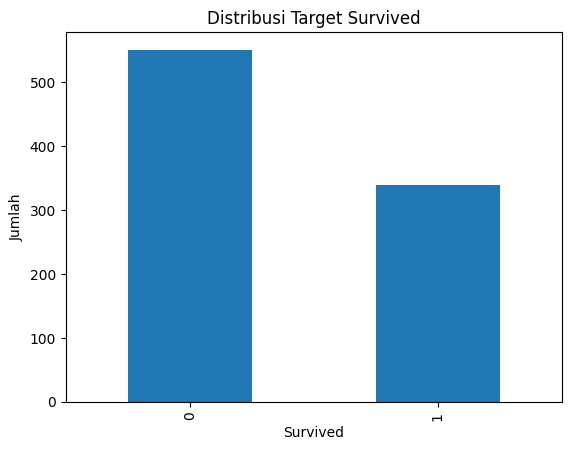

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 891
df = pd.DataFrame({
    "pclass": np.random.choice([1,2,3], n, p=[0.24,0.21,0.55]),
    "sex": np.random.choice(["male", "female"], n, p=[0.65,0.35]),
    "age": np.random.normal(30, 14, n).clip(0.5, 80),
    "sibsp": np.random.choice([0,1,2,3,4], n, p=[0.65,0.22,0.08,0.03,0.02]),
    "parch": np.random.choice([0,1,2,3], n, p=[0.75,0.15,0.08,0.02]),
    "fare": np.random.lognormal(3.0, 0.8, n),
    "embarked": np.random.choice(["S", "C", "Q"], n, p=[0.72,0.18,0.10]),
})
base_prob = 0.25 + (df["sex"].eq("female") * 0.35) + (df["pclass"].eq(1) * 0.20) - (df["pclass"].eq(3) * 0.10)
df["survived"] = (np.random.random(n) < base_prob.clip(0.05, 0.95)).astype(int)
df.loc[df.sample(177, random_state=1).index, "age"] = np.nan
df.loc[df.sample(2, random_state=2).index, "embarked"] = np.nan

cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "survived"]
df = df[cols].copy()

display(df.head())
print("Missing values:")
print(df.isnull().sum())

df["survived"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Target Survived")
plt.xlabel("Survived")
plt.ylabel("Jumlah")
plt.show()

## 2. Handling Missing Values dan Encoding


In [2]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df_encoded = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True, dtype=int)
display(df_encoded.head())


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,2,60.202315,3,0,20.641878,1,0,0,0
1,3,21.519991,0,0,28.198069,1,0,0,1
2,3,30.965354,0,0,20.729497,1,1,0,0
3,3,30.965354,0,0,6.367917,0,0,0,1
4,1,48.224378,0,2,7.010068,0,1,0,1


## 3. Train-Test Split dan Scaling


In [3]:
X = df_encoded.drop("survived", axis=1)
y = df_encoded["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
display(X_train_scaled.head())


X_train: (712, 8)
X_test: (179, 8)


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
306,0.830566,0.221828,-0.638612,-0.489882,-0.087683,0,0,1
737,0.830566,-0.022974,-0.638612,-0.489882,-0.869325,1,0,1
202,-1.558780,-0.022974,-0.638612,-0.489882,-0.590610,1,0,1
726,-1.558780,-0.022974,-0.638612,-0.489882,-0.522651,0,0,1
309,-0.364107,-0.644144,-0.638612,2.416749,-0.487988,0,0,0


## Kesimpulan

Saya mempelajari preprocessing data untuk Machine Learning. Temuan utama adalah split harus dilakukan sebelum scaling agar tidak terjadi data leakage. Keterbatasannya, notebook ini belum melatih model prediksi.
